# Step 3: ELT Pipeline Implementation — Olist Customer Analytics Project

**Owner:** Step 3 / ELT Pipeline  
**Tooling:** BigQuery + dbt + SQL  
**Business Problem:** *Which customers are most likely to become repeat buyers?*

This notebook documents the full Step 3 implementation covering the reasoning behind each model, every new field created, and how the transformations support the project’s customer retention objective.

---

## What this notebook covers

1. Project setup and dbt configuration
2. Source table registration
3. Staging layer design and rationale
4. Star schema implementation
5. Order payment aggregation
6. Customer purchase history construction
7. Customer RFM mart construction
8. Data quality tests
9. Execution results and validation
10. How the final output answers the business problem


# 1. Business Context

## Business problem

Olist wants to identify customers who are most likely to become repeat buyers.

Customer acquisition is expensive, so the company benefits from knowing:

- Which customers already buy repeatedly
- Which customers spend the most
- Which customers are inactive and may churn
- Which customer groups should receive retention campaigns or personalized promotions

## Why raw data is not enough

The raw Olist data is split across many operational tables:

- `customers` tells us who the customer is
- `orders` tells us when an order happened
- `order_payments` tells us how much was paid
- `order_items` tells us what was bought
- `products`, `sellers`, and `reviews` provide descriptive context

However, no raw table directly says:

```text
customer_unique_id | recency_days | frequency | monetary_value | customer_segment
```

Therefore, Step 3 transforms raw data into customer-level analytical outputs using dbt.


## 2. High-Level ELT Pipeline Flow

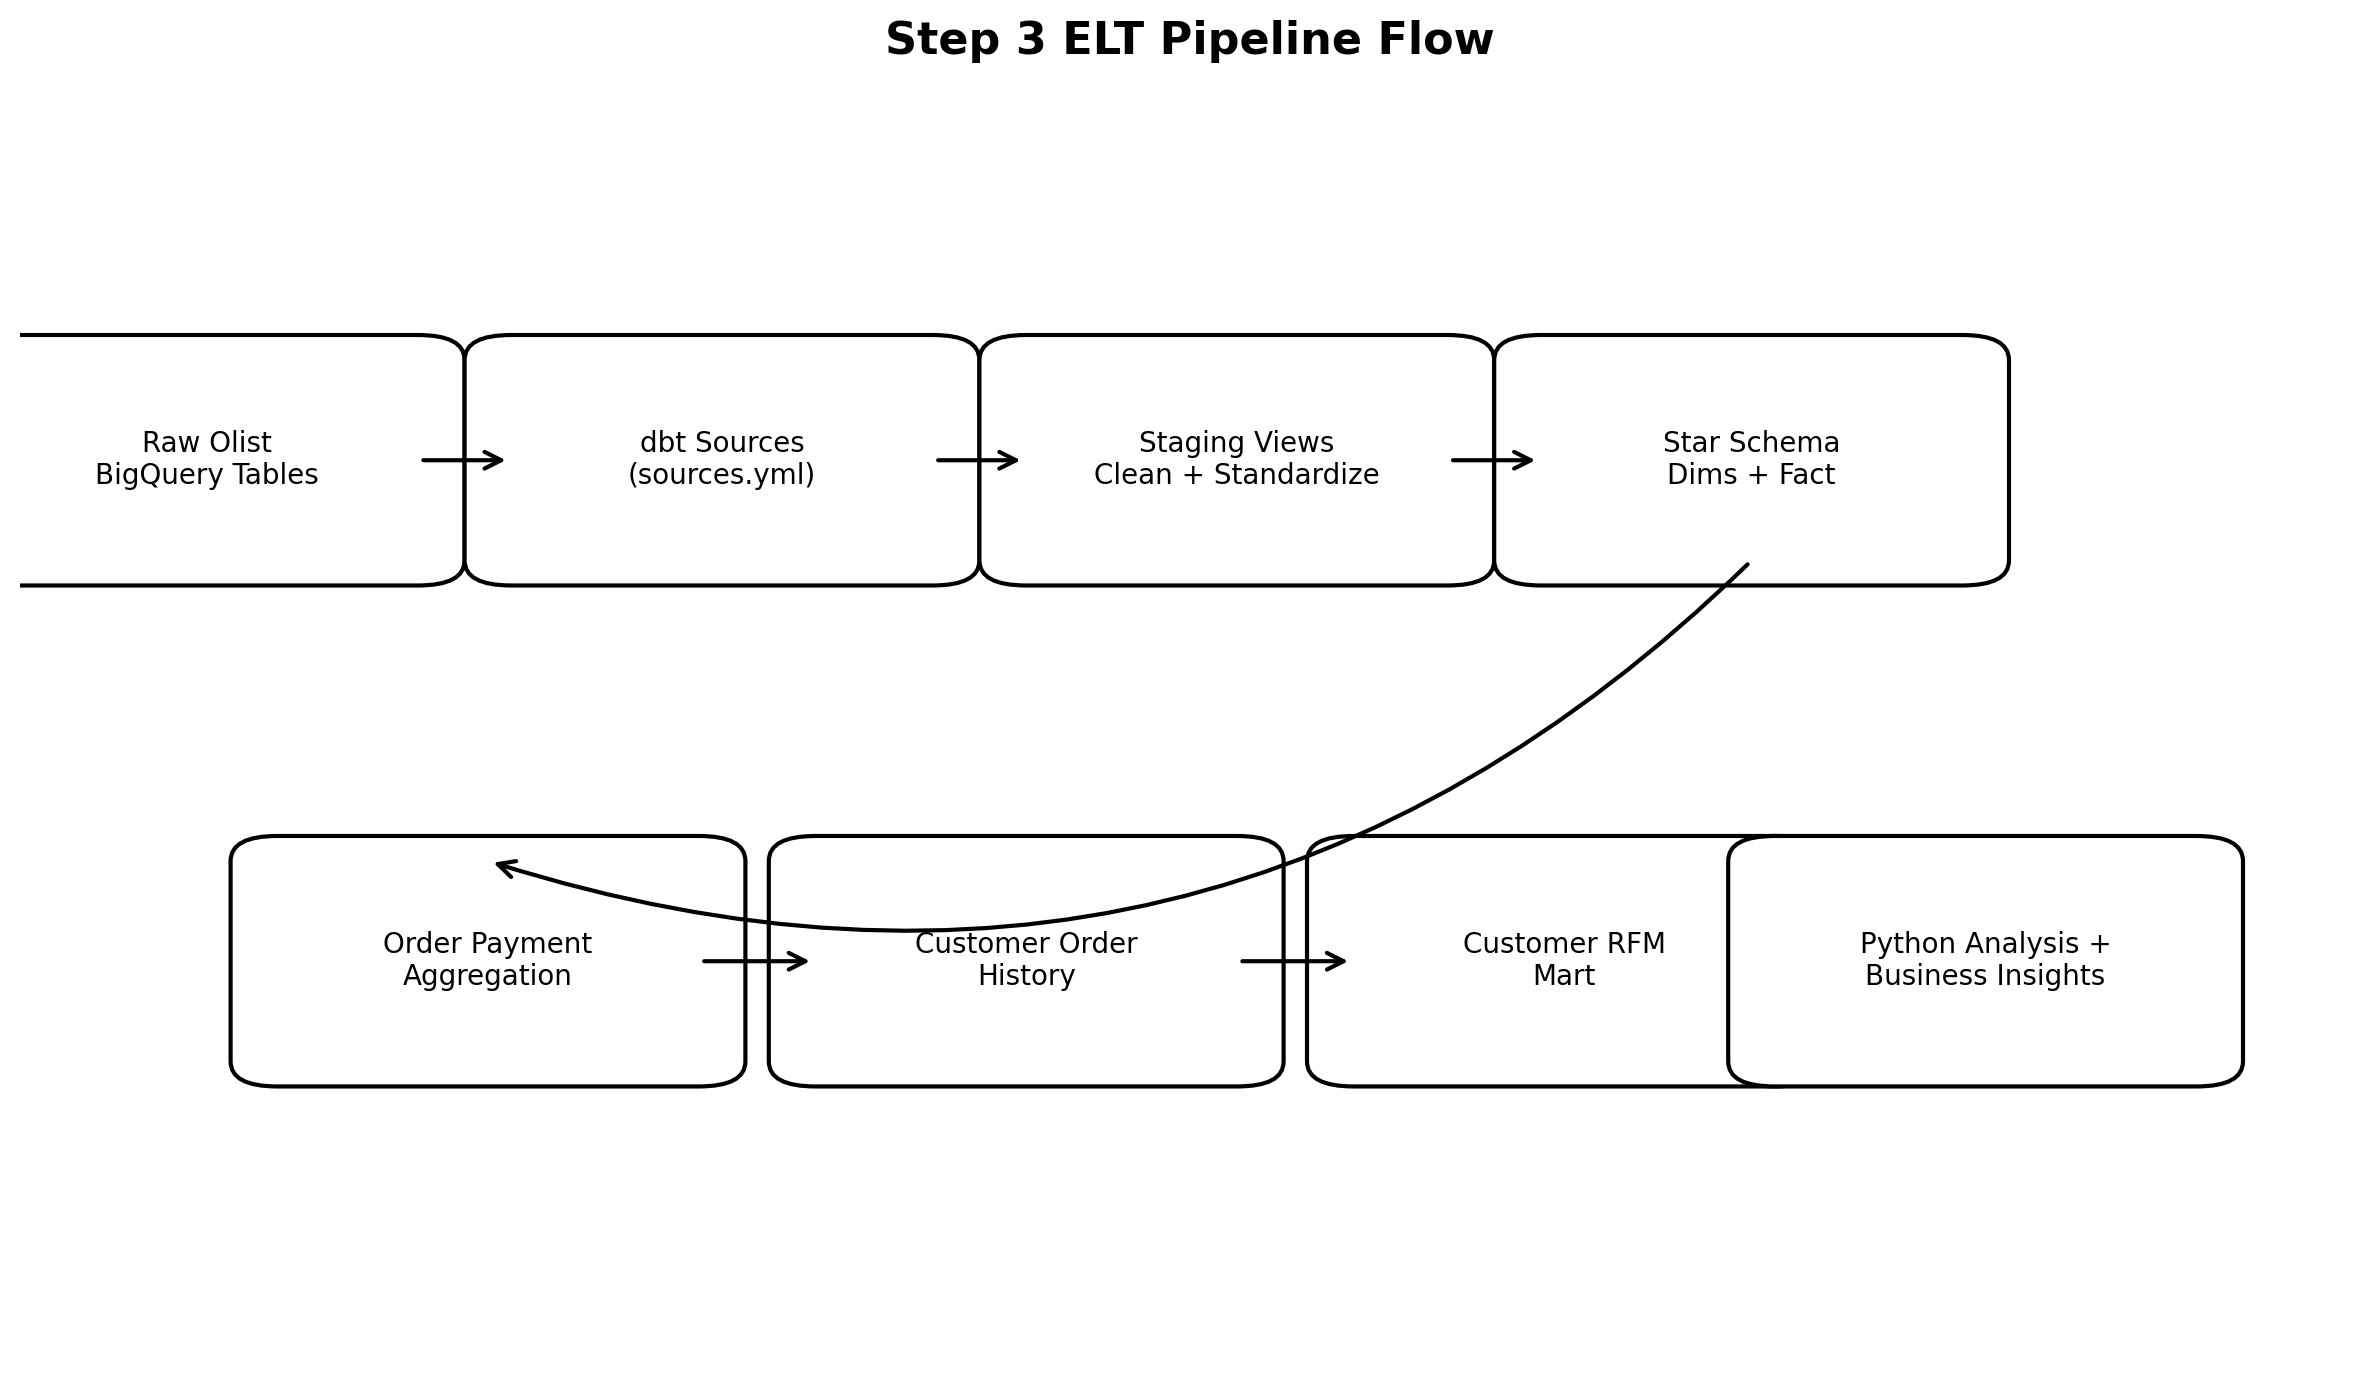

## Pipeline interpretation

The Step 3 ELT pipeline follows this structure:

```text
Raw Olist BigQuery Tables
        ↓
dbt Source Definitions
        ↓
Staging Views
        ↓
Star Schema Tables
        ↓
Business Intermediate Models
        ↓
Customer RFM Mart
        ↓
Python Analysis / Executive Insights (Step 4)
```

Each layer has a clear purpose:

| Layer | Purpose |
|---|---|
| Raw source tables | Store original ingested Olist data |
| Staging views | Clean, cast, rename, and standardize raw fields |
| Star schema | Organize data into facts and dimensions for analytical querying |
| Intermediate models | Build order revenue and customer purchase history |
| RFM mart | Produce final customer-level repeat-buyer metrics |


# 3. Environment and Setup

## 3.1 Activate the project environment

The project was run from a conda environment named `elt`.

```bash
conda activate elt
```

## Why this matters

A dedicated environment ensures that dbt, the BigQuery adapter, and Python dependencies are isolated from other projects. This reduces version conflicts and makes the project easier to reproduce.


In [ ]:
# Terminal command, shown here for documentation
# conda activate elt

## 3.2 Navigate to the dbt project folder

The ELT work was implemented inside the `dbt_olist` folder.

```bash
cd dbt_olist
```

This folder contains the dbt project files such as:

```text
dbt_project.yml
profiles.yml
sources.yml
models/
  staging/
  marts/
```


In [ ]:
# Terminal command, shown here for documentation
# cd dbt_olist

## 3.3 Validate the dbt project before running transformations

Before running the pipeline, the project was parsed.

```bash
dbt parse
```

## Rationale

`dbt parse` checks the project without creating tables or views in BigQuery.

It validates:

- SQL syntax
- Jinja syntax such as `{{ ref(...) }}` and `{{ source(...) }}`
- model dependencies
- `sources.yml`
- `schema.yml`

This step helps catch configuration or syntax issues early.

## Result

The project parsed successfully, meaning dbt could understand all model files and dependencies.


In [ ]:
# Terminal command, shown here for documentation
# dbt parse

# 4. dbt Source Configuration

## What was done

The raw Olist tables were registered in `sources.yml`.

This allows staging models to reference raw tables using dbt's `source()` function.

## Why this was done

Using `source()` is preferred because it avoids hardcoding raw BigQuery table paths in every SQL model.

Instead of writing a full BigQuery path repeatedly, we can use:

```sql
{{ source('olist_raw', 'customers') }}
```

If the raw dataset changes later, only `sources.yml` needs to be updated.


In [ ]:
# sources.yml
version: 2

sources:
  - name: olist_raw
    database: olist-assignment-497915
    schema: olist_raw
    tables:
      - name: customers
      - name: orders
      - name: order_items
      - name: order_payments
      - name: products
      - name: sellers
      - name: order_reviews

## Source table relevance to the problem statement

| Source table | Why it matters |
|---|---|
| `customers` | Provides customer identifiers and location |
| `orders` | Provides purchase dates and order status |
| `order_payments` | Provides payment value for monetary calculations |
| `order_items` | Supports item-level star schema analysis |
| `products` | Enables future product/category analysis |
| `sellers` | Enables future seller performance analysis |
| `order_reviews` | Enables future satisfaction/retention analysis |

The core tables for repeat-buyer analysis are:

```text
customers + orders + order_payments
```


# 5. Staging Layer

## What was done

The staging layer was created to clean and standardize raw source tables before they flow into final marts.

Staging models created:

```text
stg_customers
stg_orders
stg_order_items
stg_payments
stg_products
stg_sellers
stg_reviews
```

## Why staging is needed

Raw tables usually reflect operational systems. They are not always easy for analysts to use directly.

The staging layer gives each raw table a cleaner, more consistent structure by:

- Casting dates and numeric fields
- Standardizing text casing
- Filtering invalid structural IDs
- Creating basic derived fields
- Keeping one staging model per raw source table

This makes downstream marts easier to build and understand.


## 5.1 `stg_customers`

### Purpose

Clean customer identifiers and customer location fields.

### Final model logic

In [ ]:
{{ config(materialized='view') }}

select
    trim(customer_id) as customer_id,
    trim(customer_unique_id) as customer_unique_id,
    cast(customer_zip_code_prefix as int64) as customer_zip_code_prefix,
    lower(trim(customer_city)) as customer_city,
    upper(trim(customer_state)) as customer_state
from {{ source('olist_raw', 'customers') }}
where customer_id is not null
  and customer_unique_id is not null

### Field rationale

| Field | Why it was kept or created | How it helps solve the problem |
|---|---|---|
| `customer_id` | Order-level customer key used by the orders table | Allows orders to be joined back to customer records |
| `customer_unique_id` | Real customer identifier across multiple orders | Essential for repeat-buyer analysis because repeat purchases must be grouped by the same real customer |
| `customer_zip_code_prefix` | Location attribute | Supports geographic analysis |
| `customer_city` | Standardized to lowercase and trimmed | Avoids duplicate city values caused by inconsistent formatting |
| `customer_state` | Standardized to uppercase and trimmed | Supports reliable state-level analysis |

`customer_unique_id` is the most important customer field because RFM requires one row per real customer.

## 5.2 `stg_orders`

### Purpose

Clean order records and create a date field for time-based customer analysis.

### Final model logic

In [ ]:
{{ config(materialized='view') }}

select
    trim(order_id) as order_id,
    trim(customer_id) as customer_id,
    lower(trim(order_status)) as order_status,
    cast(order_purchase_timestamp as timestamp) as order_purchase_timestamp,
    date(cast(order_purchase_timestamp as timestamp)) as order_purchase_date,
    cast(order_approved_at as timestamp) as order_approved_at,
    cast(order_delivered_carrier_date as timestamp) as order_delivered_carrier_date,
    cast(order_delivered_customer_date as timestamp) as order_delivered_customer_date,
    cast(order_estimated_delivery_date as timestamp) as order_estimated_delivery_date
from {{ source('olist_raw', 'orders') }}
where order_id is not null
  and customer_id is not null

### Field rationale

| Field | Why it was kept or created | How it helps solve the problem |
|---|---|---|
| `order_id` | Unique order identifier | Links orders to payments, items, and reviews |
| `customer_id` | Customer key on the order | Allows orders to be joined to customers |
| `order_status` | Standardized status field | Allows filtering to completed purchases only |
| `order_purchase_timestamp` | Exact order purchase time | Preserves full transaction timing |
| `order_purchase_date` | New date-only field from timestamp | Required for recency calculation in RFM |
| `order_approved_at` | Order approval timestamp | Useful for future operational analysis |
| `order_delivered_carrier_date` | Carrier delivery timestamp | Useful for future delivery analysis |
| `order_delivered_customer_date` | Customer delivery timestamp | Useful for future delivery performance analysis |
| `order_estimated_delivery_date` | Estimated delivery timestamp | Useful for future delay analysis |

`order_purchase_date` was created because recency is calculated as analysis date minus last purchase date.

## 5.3 `stg_payments`

### Purpose

Clean payment records and prepare payment value for revenue calculations.

### Final model logic

In [ ]:
{{ config(materialized='view') }}

select
    trim(order_id) as order_id,
    cast(payment_sequential as int64) as payment_sequential,
    lower(trim(payment_type)) as payment_type,
    cast(payment_installments as int64) as payment_installments,
    cast(payment_value as numeric) as payment_value
from {{ source('olist_raw', 'order_payments') }}
where order_id is not null
  and payment_value is not null
  and cast(payment_value as numeric) >= 0

### Field rationale

| Field | Why it was kept or created | How it helps solve the problem |
|---|---|---|
| `order_id` | Links payment to order | Needed to attach revenue to each purchase |
| `payment_sequential` | Preserves payment sequence | Helps identify orders with multiple payment rows |
| `payment_type` | Standardized payment method | Enables optional payment behavior analysis |
| `payment_installments` | Number of installments used | Can help analyze whether installment usage affects spending |
| `payment_value` | Cast to numeric | Required for revenue and monetary value calculations |

Payment data needs aggregation because one order can have multiple payment rows.

## 5.4 `stg_order_items`

### Purpose

Clean order item records and create an item-level total value.

### Final model logic

In [ ]:
{{ config(materialized='view') }}

select
    trim(order_id) as order_id,
    cast(order_item_id as int64) as order_item_id,
    trim(product_id) as product_id,
    trim(seller_id) as seller_id,
    cast(shipping_limit_date as timestamp) as shipping_limit_date,
    cast(price as numeric) as price,
    cast(freight_value as numeric) as freight_value,
    cast(price as numeric) + cast(freight_value as numeric) as total_item_value
from {{ source('olist_raw', 'order_items') }}
where order_id is not null
  and product_id is not null
  and seller_id is not null

### Field rationale

| Field | Why it was kept or created | How it helps solve the problem |
|---|---|---|
| `order_id` | Connects item to order | Allows item-level data to join to order/customer data |
| `order_item_id` | Item number inside each order | Used to create an order-item grain fact table |
| `product_id` | Product key | Connects order item to product dimension |
| `seller_id` | Seller key | Connects order item to seller dimension |
| `shipping_limit_date` | Shipping deadline | Useful for future operational analysis |
| `price` | Item price | Core sales measure |
| `freight_value` | Shipping cost | Supports freight and item cost analysis |
| `total_item_value` | New field: `price + freight_value` | Provides item-level total amount for sales analysis |

`total_item_value` supports the assignment requirement to create total columns.

## 5.5 `stg_products`, `stg_sellers`, and `stg_reviews`

These models support the wider warehouse and future analyses.

| Model | Purpose | Relevance to repeat-buyer problem |
|---|---|---|
| `stg_products` | Cleans product attributes such as category and dimensions | Allows future analysis of which product categories drive repeat purchase |
| `stg_sellers` | Cleans seller location details | Allows future seller-retention analysis |
| `stg_reviews` | Cleans review scores and comments | Allows future analysis of satisfaction and repeat purchase behavior |

These tables are not the core of RFM, but they make the warehouse more complete and support additional business questions.


## 6. Star Schema Visual

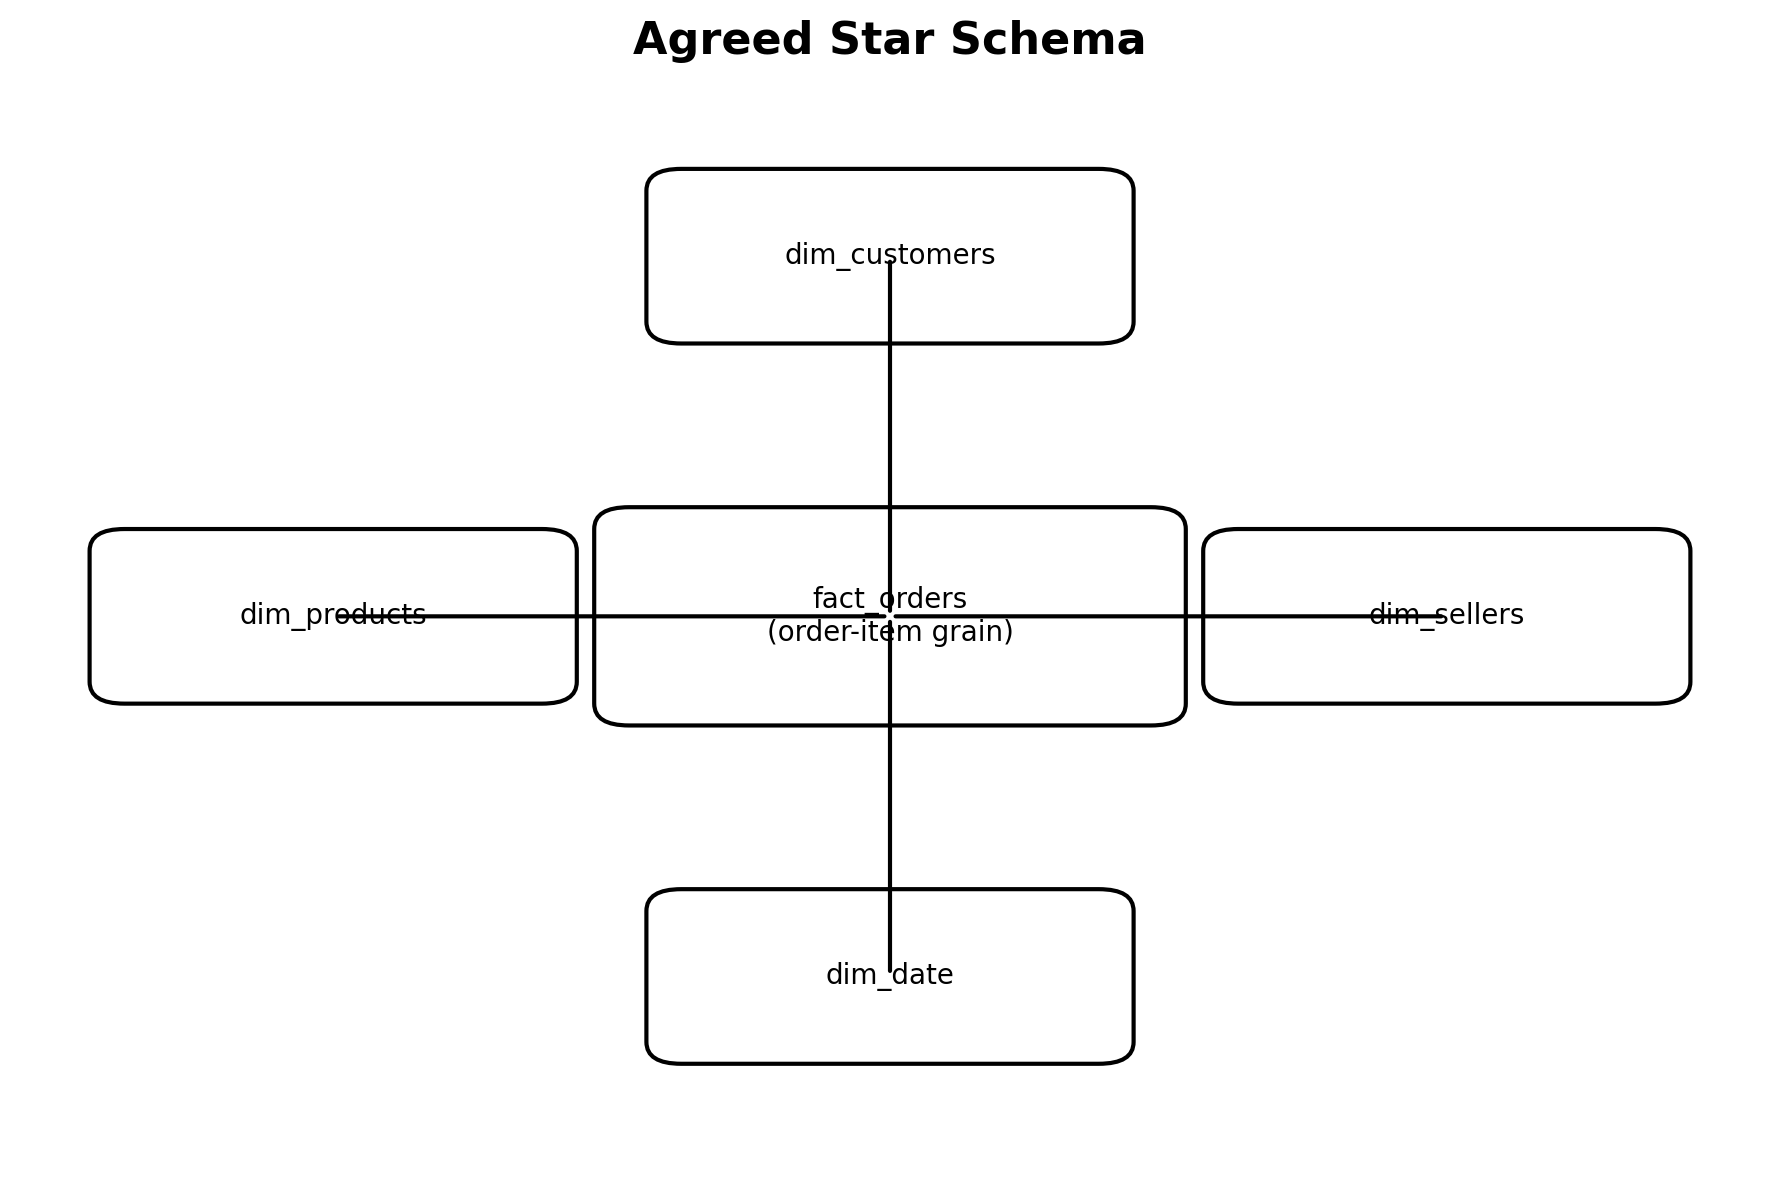

# 7. Star Schema Implementation

## What was done

The team’s agreed star schema was implemented in the marts layer.

Dimension tables:

```text
dim_customers
dim_products
dim_sellers
dim_date
```

Fact table:

```text
fact_orders
```

## Why a star schema was used

A star schema separates measurable events from descriptive context.

- `fact_orders` tells us what happened.
- `dim_customers`, `dim_products`, `dim_sellers`, and `dim_date` explain who, what, where, and when.

This makes the data easier for analysts to query.


## 7.1 `fact_orders`

### Purpose

Create a central transactional fact table at order-item level.

### Grain

```text
1 row = 1 item within an order
```

This means one order with three items will have three rows in `fact_orders`.

### Final model logic


In [ ]:
{{ config(materialized='table') }}

with staging_order_items as (
    select * from {{ ref('stg_order_items') }}
),
staging_orders as (
    select * from {{ ref('stg_orders') }}
)
select
    concat(i.order_id, '-', cast(i.order_item_id as string)) as order_item_sk,
    i.order_id as order_key,
    i.product_id as product_key,
    i.seller_id as seller_key,
    o.customer_id as customer_key,
    cast(format_date('%Y%m%d', date(o.order_purchase_timestamp)) as string) as date_key,
    i.price,
    i.freight_value,
    i.total_item_value
from staging_order_items i
left join staging_orders o
    on i.order_id = o.order_id
where o.order_id is not null

### Field rationale

| Field | Why it was created | How it helps |
|---|---|---|
| `order_item_sk` | Unique surrogate key using `order_id + order_item_id` | Ensures each fact row is uniquely identifiable |
| `order_key` | Foreign key to order | Preserves the original order reference |
| `product_key` | Foreign key to product dimension | Enables product/category analysis |
| `seller_key` | Foreign key to seller dimension | Enables seller performance analysis |
| `customer_key` | Foreign key to customer dimension | Connects purchases to customers |
| `date_key` | Foreign key to date dimension | Enables time-based analysis |
| `price` | Item price | Core item-level sales metric |
| `freight_value` | Shipping cost | Supports logistics and cost analysis |
| `total_item_value` | Price plus freight | Supports item-level total sales analysis |

Important: `fact_orders` supports the warehouse design, but repeat-buyer analysis requires customer-level aggregation. This is why `int_order_payments`, `int_customer_orders`, and `fct_customer_rfm` were added.


# 8. Business Model 1 — `int_order_payments`

## Purpose

Aggregate payment records into one revenue value per order.

## Why this model was needed

The payments table can have multiple rows for one order. If we joined raw payments directly to customers, customer spending could be duplicated or miscalculated.

## Visual example

```text
Raw payments
order_id | payment_value
O1       | 50
O1       | 50
O2       | 120

After int_order_payments
order_id | order_revenue
O1       | 100
O2       | 120
```

## Final model logic


In [ ]:
{{ config(materialized='view') }}

select
    order_id,
    sum(payment_value) as order_revenue,
    count(*) as payment_row_count,
    max(payment_installments) as max_payment_installments
from {{ ref('stg_payments') }}
group by order_id

## Field rationale

| Field | Why it was created | How it helps solve the problem |
|---|---|---|
| `order_id` | Groups payment rows by order | Creates one payment summary per order |
| `order_revenue` | `sum(payment_value)` | Provides the revenue generated by each order; this feeds customer monetary value |
| `payment_row_count` | Counts payment rows per order | Helps identify orders split across multiple payment records |
| `max_payment_installments` | Maximum installment count per order | Keeps payment behavior information for future analysis |

`order_revenue` matters because RFM monetary value is the sum of order revenue across each customer's completed orders.


# 9. Business Model 2 — `int_customer_orders`

## Purpose

Build a complete customer purchase history by joining customers, orders, and order revenue.

## Why this model was needed

Before this model, information was split across separate tables:

```text
stg_customers → who the customer is
stg_orders → when the purchase happened
int_order_payments → how much the order was worth
```

`int_customer_orders` combines these into one customer-order-level dataset.

## Visual

```text
stg_customers
      +
stg_orders
      +
int_order_payments
      ↓
int_customer_orders
```

## Final model logic


In [ ]:
{{ config(materialized='view') }}

with orders as (
    select * from {{ ref('stg_orders') }}
),
customers as (
    select * from {{ ref('stg_customers') }}
),
payments as (
    select * from {{ ref('int_order_payments') }}
)
select
    c.customer_unique_id,
    c.customer_id,
    c.customer_city,
    c.customer_state,
    o.order_id,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_purchase_date,
    coalesce(p.order_revenue, 0) as order_revenue
from orders o
left join customers c
    on o.customer_id = c.customer_id
left join payments p
    on o.order_id = p.order_id
where o.order_status = 'delivered'

## Field rationale

| Field | Why it was created | How it helps solve the problem |
|---|---|---|
| `customer_unique_id` | Groups orders by real customer | Required to identify repeat buyers correctly |
| `customer_id` | Maintains order-level customer link | Useful for traceability back to raw data |
| `customer_city` | Customer location | Enables regional repeat-buyer analysis |
| `customer_state` | Customer state | Enables state-level customer segmentation |
| `order_id` | Identifies each purchase event | Used to count frequency |
| `order_status` | Indicates completed vs incomplete orders | Used to filter only delivered purchases |
| `order_purchase_timestamp` | Exact purchase timestamp | Preserves transaction timing |
| `order_purchase_date` | Date version of purchase time | Used in recency calculations |
| `order_revenue` | Revenue per completed order | Used to calculate monetary value |

Only delivered orders were used because canceled or unavailable orders should not count as successful purchases. `coalesce(order_revenue, 0)` was used to avoid null revenue breaking RFM calculations while preserving valid delivered purchase records.


# 10. Final Business Mart — `fct_customer_rfm`

## Purpose

Create a customer-level table that directly answers the problem statement.

## What RFM means

```text
R = Recency: how recently the customer purchased
F = Frequency: how often the customer purchased
M = Monetary: how much the customer spent
```

## Final model logic


In [ ]:
{{ config(materialized='table') }}

with customer_orders as (
    select * from {{ ref('int_customer_orders') }}
),
analysis_date as (
    select max(order_purchase_date) as max_order_date
    from customer_orders
),
rfm as (
    select
        customer_unique_id,
        min(order_purchase_date) as first_purchase_date,
        max(order_purchase_date) as last_purchase_date,
        date_diff(
            (select max_order_date from analysis_date),
            max(order_purchase_date),
            day
        ) as recency_days,
        count(distinct order_id) as frequency,
        sum(coalesce(order_revenue, 0)) as monetary_value,
        avg(coalesce(order_revenue, 0)) as avg_order_value
    from customer_orders
    group by customer_unique_id
)
select
    customer_unique_id,
    first_purchase_date,
    last_purchase_date,
    recency_days,
    frequency,
    monetary_value,
    avg_order_value,
    case when frequency >= 2 then true else false end as is_repeat_buyer,
    case when recency_days > 180 then true else false end as is_churn_risk,
    case
        when recency_days <= 90 and frequency >= 2 and monetary_value >= 300 then 'Champions'
        when recency_days <= 180 and frequency >= 2 then 'Loyal Customers'
        when recency_days > 180 and frequency >= 2 then 'At-Risk Customers'
        when frequency = 1 and recency_days > 180 then 'Lost Customers'
        else 'New / Low Activity Customers'
    end as customer_segment
from rfm

## Field-by-field rationale for `fct_customer_rfm`

| Field | Formula / Logic | Why it was created | How it helps solve the problem |
|---|---|---|---|
| `customer_unique_id` | Grouping key | Identifies each real customer | Ensures repeat purchases are grouped correctly |
| `first_purchase_date` | `min(order_purchase_date)` | Shows when the customer first purchased | Helps understand customer tenure |
| `last_purchase_date` | `max(order_purchase_date)` | Shows most recent purchase date | Required for recency |
| `recency_days` | Analysis date minus last purchase date | Measures how recently customer purchased | Recent customers are more likely to return |
| `frequency` | `count(distinct order_id)` | Counts number of completed orders | Directly identifies repeat buyers |
| `monetary_value` | `sum(order_revenue)` | Measures total customer spend | Identifies high-value customers |
| `avg_order_value` | `avg(order_revenue)` | Measures average spend per order | Differentiates frequent low spenders from high spenders |
| `is_repeat_buyer` | `frequency >= 2` | Boolean repeat-buyer flag | Direct answer to the repeat-buyer question |
| `is_churn_risk` | `recency_days > 180` | Flags inactive customers | Supports retention/reactivation campaigns |
| `customer_segment` | RFM business rules | Converts metrics into business-friendly groups | Makes output actionable for marketing and executives |

Customer segmentation translates raw metrics into actionable categories such as `Champions`, `Loyal Customers`, `At-Risk Customers`, and `Lost Customers`.


# 11. Data Quality Testing with `schema.yml`

## What was done

Data tests were added to validate important fields.

Test types used:

```text
not_null
unique
relationships
```

## Why tests were needed

RFM analysis is only useful if the underlying data is reliable.

For example:

- If `customer_unique_id` is null, we cannot identify the customer.
- If `order_revenue` is null, monetary value may be wrong.
- If fact table keys do not match dimension keys, the star schema is unreliable.

## Example schema tests


In [ ]:
version: 2

models:
  - name: fct_customer_rfm
    columns:
      - name: customer_unique_id
        tests:
          - not_null
          - unique
      - name: recency_days
        tests:
          - not_null
      - name: frequency
        tests:
          - not_null
      - name: monetary_value
        tests:
          - not_null
      - name: customer_segment
        tests:
          - not_null

  - name: fact_orders
    columns:
      - name: order_item_sk
        tests:
          - not_null
          - unique
      - name: customer_key
        tests:
          - not_null
          - relationships:
              to: ref('dim_customers')
              field: customer_key

## Test rationale

| Test | Why it was used | Example |
|---|---|---|
| `not_null` | Critical fields must not be missing | `customer_unique_id`, `monetary_value`, `order_revenue` |
| `unique` | Primary keys should not duplicate | `order_item_sk`, `customer_unique_id` in RFM |
| `relationships` | Fact keys must exist in dimension tables | `fact_orders.customer_key → dim_customers.customer_key` |

Passing tests gives confidence that the RFM table can be used for downstream Python analysis and executive reporting.


# 12. Pipeline Execution and Validation

## Build models

```bash
dbt run
```

Final build result:

```text
PASS=15
WARN=0
ERROR=0
SKIP=0
TOTAL=15
```

## Run tests

```bash
dbt test
```

Final test result:

```text
PASS=47
WARN=0
ERROR=0
SKIP=0
TOTAL=47
```

This confirms that all models built successfully and all data quality tests passed.


In [ ]:
# Terminal commands, shown here for documentation
# dbt run
# dbt test

# 13. Debugging and Fix Applied

## Issue found during testing

During testing, two tests initially failed:

```text
not_null_int_customer_orders_order_revenue
not_null_fct_customer_rfm_monetary_value
```

## Root cause

One delivered order had no matching payment record, which caused null revenue values.

## Fix applied

The model was updated with:

```sql
coalesce(order_revenue, 0)
```

and:

```sql
sum(coalesce(order_revenue, 0))
```

## Why this fix was selected

The delivered order was still a valid customer purchase event. Removing it would lose purchase behavior. Setting missing revenue to 0 preserved the order while preventing null values from breaking RFM calculations.

## Result after fix

```text
dbt test → PASS=47 WARN=0 ERROR=0
```


# 14. Final Models Created

| Category | Models |
|---|---|
| Staging | `stg_customers`, `stg_orders`, `stg_order_items`, `stg_payments`, `stg_products`, `stg_sellers`, `stg_reviews` |
| Dimensions | `dim_customers`, `dim_products`, `dim_sellers`, `dim_date` |
| Fact | `fact_orders` |
| Business intermediate models | `int_order_payments`, `int_customer_orders` |
| Final business mart | `fct_customer_rfm` |

The most important output for the business problem is `fct_customer_rfm` because it is the customer-level table that directly supports repeat-buyer analysis.


# 15. How the ELT Pipeline Solves the Problem Statement

## Problem statement

```text
Which customers are most likely to become repeat buyers?
```

## Solution path

```text
1. Clean customer, order, and payment data
2. Aggregate payments into order revenue
3. Join customers to their completed orders
4. Summarize customer behavior with RFM metrics
5. Assign repeat-buyer and churn-risk flags
6. Create business-friendly customer segments
```

## Final fields that answer the problem

| Final field | Business meaning |
|---|---|
| `frequency` | Number of times a customer purchased |
| `is_repeat_buyer` | Whether the customer has purchased at least twice |
| `recency_days` | How recently the customer purchased |
| `is_churn_risk` | Whether the customer has been inactive for a long time |
| `monetary_value` | Total customer spend |
| `avg_order_value` | Average spend per order |
| `customer_segment` | Actionable customer group |

Example interpretation:

```text
Low recency_days + frequency >= 2 + high monetary_value = valuable repeat buyer
High recency_days + low frequency = lost or churn-risk customer
```


# 16. Business Value

The completed Step 3 ELT pipeline enables Olist to:

- Identify repeat buyers
- Identify high-value customers
- Identify customers at risk of churn
- Build targeted marketing campaigns
- Improve retention strategy
- Increase customer lifetime value
- Reduce reliance on expensive customer acquisition

## Executive-friendly summary

The ELT pipeline turns raw transaction data into customer intelligence. Instead of only seeing individual orders, the business can now see customer behavior over time.


# 17. Final Checklist

| Requirement | Status |
|---|---|
| Raw data connected through dbt sources | Complete |
| Staging models created | Complete |
| Data cleaning implemented | Complete |
| Star schema implemented | Complete |
| Order revenue aggregation created | Complete |
| Customer purchase history created | Complete |
| RFM mart created | Complete |
| Repeat-buyer flag created | Complete |
| Churn-risk flag created | Complete |
| Customer segmentation created | Complete |
| dbt run successful | Complete |
| dbt test successful | Complete |

Final validation:

```text
dbt run  → 15 models passed
dbt test → 47 tests passed
```


# 18. Recommended Next Step for Analysis 

The Python analysis phase should use the final mart:

```text
fct_customer_rfm
```

Recommended analyses:

- Count customers by segment
- Compare revenue by segment
- Identify top high-value repeat buyers
- Analyze churn-risk customers by state
- Compare average order value by customer segment
- Recommend retention strategies for each segment

Example SQL query:

```sql
select
    customer_segment,
    count(*) as customer_count,
    sum(monetary_value) as total_revenue,
    avg(avg_order_value) as avg_order_value
from `olist-assignment-497915.olist_dwh.fct_customer_rfm`
group by customer_segment
order by total_revenue desc;
```
